# 05. IMS bearings: health indicator, onset, diagnosis & RUL

Goal: one degradation curve per bearing that
1. stays flat through healthy life *and* through rig-level events (restarts, cross-talk),
2. crosses an alarm level early enough to plan a repair,
3. tells us **what** is failing (outer race / inner race / roller),
4. supports a remaining-useful-life estimate, if the data allow one.

**Health indicator** (`vibration/health.py`):
- per bearing: log of each feature, minus the log-median of the **other bearings on the same shaft** (common-mode rejection)
- standardised against the bearing's own first 24 h (after 1 h run-in)
- HI = max one-sided z over {RMS, kurtosis, envelope BPFO / BPFI / 2×BSF}, trailing 2 h median

**Alarm** = HI above *k* healthy-σ for *p* consecutive snapshots (it clears when HI falls back below *k*). As in Module A's 72 h anticipation window, an alarm counts as a **detection** only if raised within `max_lead_hours` (168 h = 1 week) of failure. An alarm weeks earlier would have triggered an inspection that found nothing, so it is a false alarm.

In [1]:
import sys
import warnings
from pathlib import Path

# Make `src/` importable whether the notebook runs from notebooks/ or the repo root
ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from compressor_guard.config import FIGURES_DIR, load_params

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
params = load_params()

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "savefig.bbox": "tight",
                     "axes.titleweight": "bold", "axes.titlesize": 11})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
FAIL_COLOR, ALERT_COLOR, FROZEN_COLOR = "#d62728", "#ff7f0e", "#7f7f7f"

from compressor_guard.vibration.features import load_test_features
from compressor_guard.vibration.health import (ENV_BANDS, evaluate_onsets, health_indicator, health_params,
                                               onset_sweep, summarise_test)
from compressor_guard.vibration.io import EXPECTED_BAND, KNOWN_FAILURES
from compressor_guard.vibration.rul import lobo_rul

h = params["ims"]["health"]
hp = health_params(params)
features = {t: load_test_features(t, params) for t in (1, 2, 3)}
hi = pd.concat([health_indicator(features[t], **hp) for t in (1, 2, 3)], ignore_index=True)
hi_noref = pd.concat([health_indicator(features[t], **{**hp, "reference": "none"}) for t in (1, 2, 3)],
                     ignore_index=True)
hi.to_parquet(ROOT / params["ims"]["processed_dir"] / "ims_health.parquet", index=False)
print(f"HI computed for {hi.groupby(['test', 'bearing']).ngroups} bearings")

HI computed for 12 bearings


## 1. Why common-mode rejection matters (test 1 restart)

Test 1 stopped for ~148 h at hour 170. When it restarted, **every** bearing's vibration moved. A per-bearing baseline alone reads this as degradation in all four bearings at once.

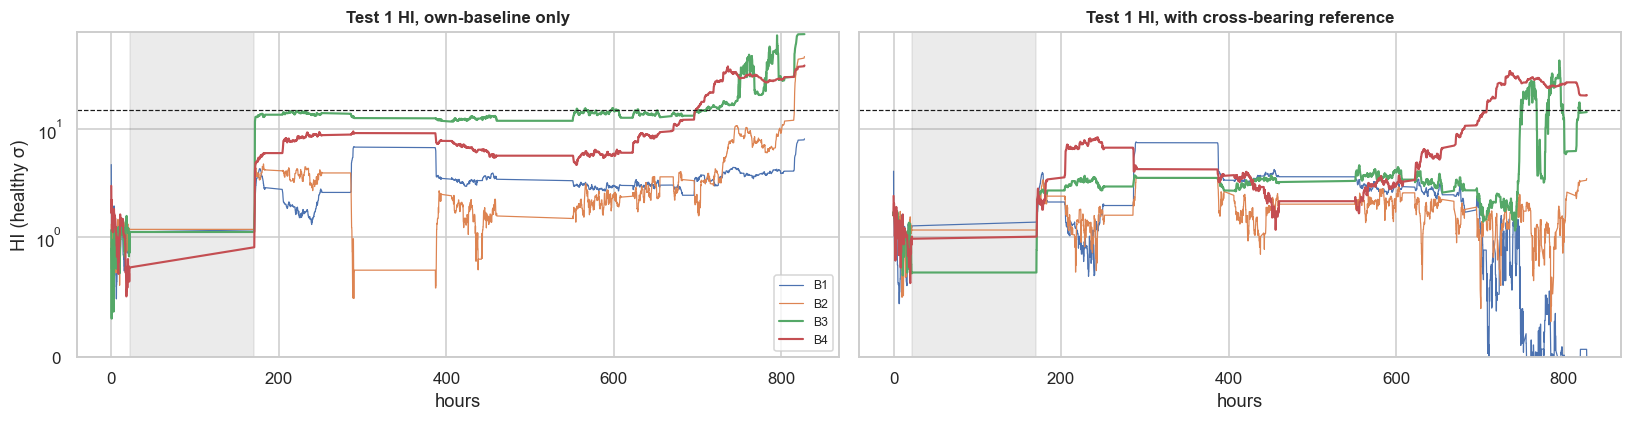

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
for ax, d, title in [(axes[0], hi_noref, "own-baseline only"), (axes[1], hi, "with cross-bearing reference")]:
    for b, g in d[d["test"] == 1].groupby("bearing"):
        ax.plot(g["hours"], g["hi"], lw=1.4 if (1, b) in KNOWN_FAILURES else 0.8, label=f"B{b}")
    ax.axhline(h["onset_k"], color="k", ls="--", lw=0.8)
    ax.axvspan(170.5 - 148.4, 170.5, color=FROZEN_COLOR, alpha=0.15)
    ax.set_yscale("symlog", linthresh=1); ax.set_ylim(bottom=0); ax.set_title(f"Test 1 HI, {title}"); ax.set_xlabel("hours")
axes[0].set_ylabel("HI (healthy σ)"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. Choosing *k* and persistence

There are only **4 failed bearings** (and 8 that survived), so any choice is tuned on the evaluation data. The honest move is to show the whole grid and pick a configuration from a **stable plateau**, not a lucky point.

False alarms are counted rig-aware:
- alarms on a failing bearing raised more than a week before its failure count as false,
- alarms on a surviving bearing count as false only if raised *before* the first detection on its shaft. After that, the shaft is already scheduled for maintenance, and neighbour cross-talk is expected.

In [3]:
rows = []
for k in (4, 6, 8, 10, 12, 15, 20, 25):
    for p in (6, 12, 24):
        s = summarise_test(hi, k, p, h["max_lead_hours"])
        e = evaluate_onsets(s)
        f = s[s["known_failure"] != "none"].set_index(["test", "bearing"])
        rows.append({"k": k, "persistence": p, "detected": f"{e['detected']}/{e['failed']}",
                     "false_alarms": e["false_alarms"], "diagnosis_correct": int(f["diagnosis_correct"].eq(True).sum()),
                     "median_lead_h": round(e["median_lead_hours"], 1),
                     **{f"T{t}B{b} lead h": round(v, 1) if pd.notna(v) else None
                        for (t, b), v in f["hours_before_failure"].items()}})
grid = pd.DataFrame(rows)
display(grid.style.apply(lambda r: ["background-color: #fff3cd" if (r["k"] == h["onset_k"] and
                                    r["persistence"] == h["onset_persistence"]) else "" for _ in r], axis=1))

,k,persistence,detected,false_alarms,diagnosis_correct,median_lead_h,T1B3 lead h,T1B4 lead h,T2B1 lead h,T3B3 lead h
0,4,6,3/4,48,3,80.000000,80.000000,nan,73.500000,137.200000
1,4,12,3/4,36,3,77.800000,79.000000,nan,72.500000,77.800000
2,4,24,3/4,23,3,70.500000,77.000000,nan,70.500000,62.000000
3,6,6,3/4,31,3,73.200000,79.500000,nan,73.200000,57.700000
4,6,12,4/4,21,4,75.400000,78.500000,158.500000,72.200000,56.700000
5,6,24,4/4,15,4,73.400000,76.500000,155.100000,70.200000,54.700000
6,8,6,4/4,25,4,75.300000,79.200000,155.400000,71.300000,56.500000
7,8,12,4/4,17,4,74.300000,78.200000,154.400000,70.300000,55.500000
8,8,24,4/4,11,4,72.300000,76.200000,152.400000,68.300000,53.500000
9,10,6,4/4,23,4,74.000000,78.900000,146.400000,69.200000,40.700000


At low *k* the HI trips on ordinary fluctuations. Test 1 B4 fires spuriously after the restart (k ≤ 4), and the surviving test 3 B4 flaps across the threshold again and again, costing 11–31 false inspections for k ≤ 12. From **k = 15 to 25** there is a stable plateau: all four failures detected, every diagnosis right, and a single false alarm. Lead times shrink slowly as *k* rises. We use **k = 15, persistence = 12 snapshots (~2 h)** (highlighted), the most sensitive setting on the plateau.

## 3. Onset & diagnosis

In [4]:
summary = summarise_test(hi, h["onset_k"], h["onset_persistence"], h["max_lead_hours"])
display(summary.round(1))
ev = evaluate_onsets(summary)
print(f"Detected {ev['detected']}/{ev['failed']} failed bearings, median {ev['median_lead_hours']:.0f} h before failure; "
      f"{ev['false_alarms']} false alarm(s) on surviving bearings")

,test,bearing,known_failure,life_hours,onset_hours,hours_before_failure,onset_pct_life,alarm_episodes,early_false_alarms,alarm_hours,diagnosed_band,diagnosis_correct
0,1,1,none,827.6,NaN,NaN,NaN,0,0,[],None,None
1,1,2,none,827.6,NaN,NaN,NaN,0,0,[],None,None
2,1,3,inner_race,827.6,755.1,72.4,91.2,2,0,"[755.1427777777777, 783.9166666666666]",inner_race,True
3,1,4,roller_element,827.6,710.0,117.6,85.8,1,0,[709.9608333333333],roller_element,True
4,2,1,outer_race,163.8,106.2,57.7,64.8,1,0,[106.16666666666667],outer_race,True
5,2,2,none,163.8,NaN,NaN,NaN,0,0,[],None,None
6,2,3,none,163.8,NaN,NaN,NaN,0,0,[],None,None
7,2,4,none,163.8,NaN,NaN,NaN,0,0,[],None,None
8,3,1,none,1073.3,NaN,NaN,NaN,0,0,[],None,None
9,3,2,none,1073.3,NaN,NaN,NaN,0,0,[],None,None


Detected 4/4 failed bearings, median 65 h before failure; 1 false alarm(s) on surviving bearings


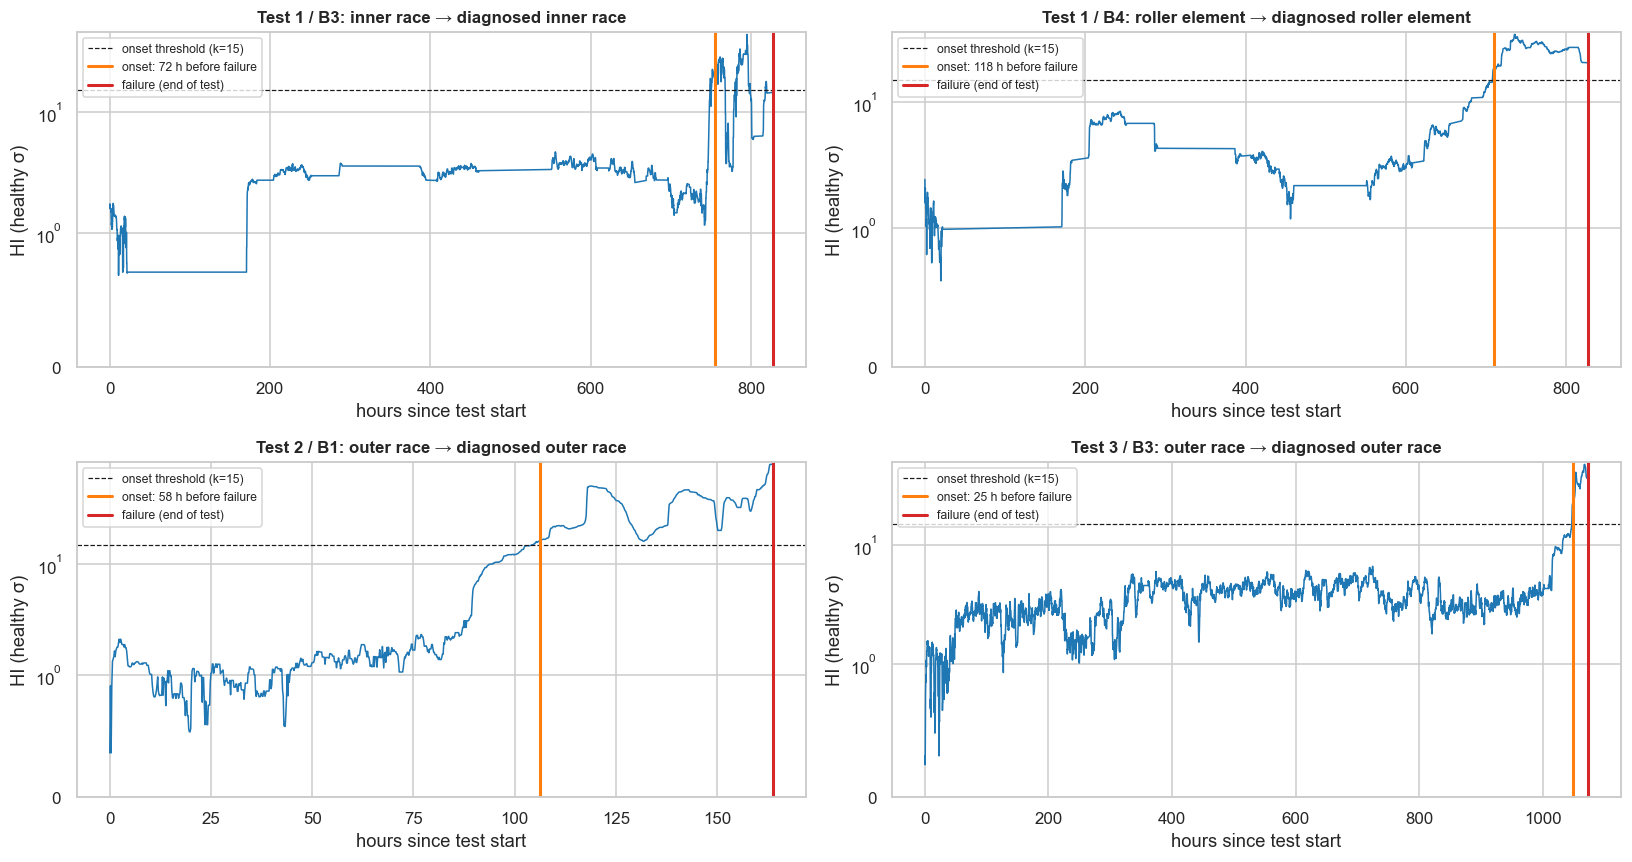

In [5]:
failed = [(t, b) for (t, b) in KNOWN_FAILURES]
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, (t, b) in zip(axes.flat, failed):
    g = hi[(hi["test"] == t) & (hi["bearing"] == b)]
    r = summary[(summary["test"] == t) & (summary["bearing"] == b)].iloc[0]
    ax.plot(g["hours"], g["hi"], color="#1f77b4", lw=1)
    ax.axhline(h["onset_k"], color="k", ls="--", lw=0.8, label=f"onset threshold (k={h['onset_k']:g})")
    if pd.notna(r["onset_hours"]):
        ax.axvline(r["onset_hours"], color=ALERT_COLOR, lw=2,
                   label=f"onset: {r['hours_before_failure']:.0f} h before failure")
    ax.axvline(g["hours"].max(), color=FAIL_COLOR, lw=2, label="failure (end of test)")
    ax.set_yscale("symlog", linthresh=1); ax.set_ylim(bottom=0)
    ax.set_title(f"Test {t} / B{b}: {KNOWN_FAILURES[(t, b)].replace('_', ' ')} → diagnosed "
                 f"{str(r['diagnosed_band']).replace('_', ' ')}")
    ax.set(xlabel="hours since test start", ylabel="HI (healthy σ)")
    ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "ims_health.png")
plt.show()

**Diagnosis.** After onset, which envelope band has moved most? Each band maps to a fault type: BPFO → outer race, BPFI → inner race, 2×BSF → rolling element.

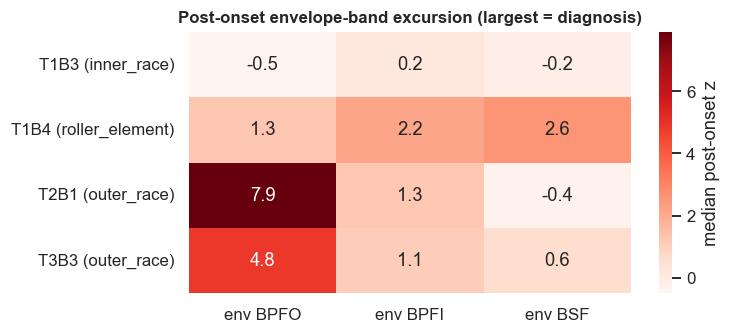

In [6]:
dx = []
for (t, b) in failed:
    r = summary[(summary["test"] == t) & (summary["bearing"] == b)].iloc[0]
    post = hi[(hi["test"] == t) & (hi["bearing"] == b) & (hi["hours"] >= r["onset_hours"])]
    dx.append(post[[f"z_{c}" for c in ENV_BANDS]].median().rename(f"T{t}B{b} ({KNOWN_FAILURES[(t, b)]})"))
dx = pd.DataFrame(dx).rename(columns=lambda c: c[2:].upper().replace("ENV_", "env "))
plt.figure(figsize=(7, 3.2))
sns.heatmap(dx, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "median post-onset z"})
plt.title("Post-onset envelope-band excursion (largest = diagnosis)")
plt.tight_layout(); plt.show()

All four failure modes are identified correctly, and the inner-race and roller cases in test 1 are separated from each other on the same shaft.

## 4. Remaining useful life

After onset we model the **RMS ratio** (RMS / the bearing's healthy RMS) as exponential growth and extrapolate to a failure level, learned **leave-one-bearing-out** (the median end-of-life RMS ratio of the *other* failed bearings). We evaluate at 50 / 75 / 90 % of each bearing's onset→failure interval.

A naive baseline for comparison: *predicted RUL = median post-onset life of the other failed bearings − time since onset*.

In [7]:
onsets = {(r.test, r.bearing): (r.onset_hours if pd.notna(r.onset_hours) else None) for r in summary.itertuples()}
rul = lobo_rul(hi, onsets, fractions=params["ims"]["rul"]["eval_fractions"],
               min_points=params["ims"]["rul"]["min_points"], max_rul=params["ims"]["rul"]["max_rul_hours"])

post_life = {k: summary.set_index(["test", "bearing"]).loc[k, "hours_before_failure"] for k in failed}
naive = []
for r in rul.itertuples():
    others = np.median([v for k, v in post_life.items() if k != (r.test, r.bearing)])
    elapsed = r.t_eval - onsets[(r.test, r.bearing)]
    naive.append(max(others - elapsed, 0.0))
rul["naive_pred_rul"] = naive
rul["naive_error_h"] = rul["naive_pred_rul"] - rul["actual_rul"]
display(rul[["test", "bearing", "failure", "eval_fraction", "own_eol_hi", "hi_fail", "actual_rul", "pred_rul",
             "error_h", "naive_pred_rul", "naive_error_h"]].round(2)
        .rename(columns={"own_eol_hi": "own_EOL_rms_ratio", "hi_fail": "LOBO_fail_level"}))

mae = rul.groupby("eval_fraction").agg(exp_model_MAE_h=("error_h", lambda s: s.abs().median()),
                                       naive_MAE_h=("naive_error_h", lambda s: s.abs().median()),
                                       actual_RUL_median_h=("actual_rul", "median"))
print("Median absolute error by evaluation point:")
display(mae.round(1))

,test,bearing,failure,eval_fraction,own_EOL_rms_ratio,LOBO_fail_level,actual_rul,pred_rul,error_h,naive_pred_rul,naive_error_h
0,1,3,inner_race,0.50,2.67,5.72,36.21,504.87,468.67,21.46,-14.75
1,1,3,inner_race,0.75,2.67,5.72,18.10,468.29,450.19,3.35,-14.75
2,1,3,inner_race,0.90,2.67,5.72,7.24,163.62,156.38,0.00,-7.24
3,1,4,roller_element,0.50,2.47,5.72,58.80,247.32,188.52,0.00,-58.80
4,1,4,roller_element,0.75,2.47,5.72,29.40,1458.64,1429.24,0.00,-29.40
5,1,4,roller_element,0.90,2.47,5.72,11.76,1955.45,1943.69,0.00,-11.76
6,2,1,outer_race,0.50,5.72,2.67,28.83,123.24,94.41,43.58,14.75
7,2,1,outer_race,0.75,5.72,2.67,14.42,36.77,22.36,29.17,14.75
8,2,1,outer_race,0.90,5.72,2.67,5.77,22.45,16.68,20.52,14.75
9,3,3,outer_race,0.50,6.35,2.67,12.33,2.18,-10.16,60.08,47.75


Median absolute error by evaluation point:


,exp_model_MAE_h,naive_MAE_h,actual_RUL_median_h
eval_fraction,,,
0.50,141.5,31.2,32.5
0.75,236.3,22.1,16.3
0.90,86.5,13.3,6.5


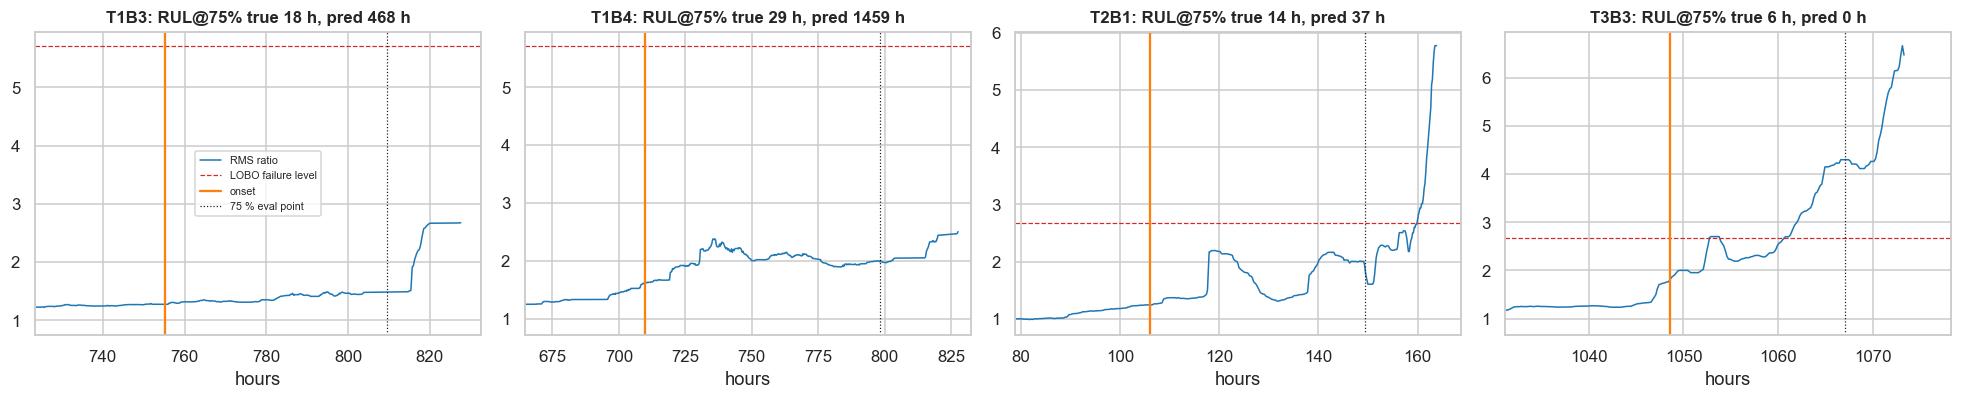

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, (t, b) in zip(axes, failed):
    g = hi[(hi["test"] == t) & (hi["bearing"] == b)]
    on = onsets[(t, b)]
    ax.plot(g["hours"], g["rms_ratio"], color="#1f77b4", lw=1, label="RMS ratio")
    rr = rul[(rul["test"] == t) & (rul["bearing"] == b) & (rul["eval_fraction"] == 0.75)].iloc[0]
    ax.axhline(rr["hi_fail"], color=FAIL_COLOR, ls="--", lw=0.8, label="LOBO failure level")
    ax.axvline(on, color=ALERT_COLOR, lw=1.5, label="onset")
    ax.axvline(rr["t_eval"], color="k", lw=0.8, ls=":", label="75 % eval point")
    ax.set_xlim(on - 0.3 * (g["hours"].max() - on) - 10, g["hours"].max() + 5)
    ax.set_title(f"T{t}B{b}: RUL@75% true {rr['actual_rul']:.0f} h, pred {rr['pred_rul']:.0f} h")
    ax.set_xlabel("hours")
axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

**The RUL results are poor, and this is reported as is.** End-of-life RMS ratios range from ~2.5× (test 1) to ~6× (tests 2 and 3), so no shared failure level exists. The inner-race bearing in test 1 barely trends before it fails, and the outer-race failures accelerate abruptly. With four heterogeneous bearings, a data-driven RUL model cannot be validated. The exponential model is worse than the naive baseline at every evaluation point (median absolute error ~90–240 h vs ~13–31 h). The failure level learned from the other bearings is simply wrong for each held-out bearing.

**Practical conclusion:** in Module B, the dependable outputs are **onset (with a median ~2–3 days of warning) and fault diagnosis**. They are what drive the maintenance-economics analysis in notebook 06. RUL should be treated as future work that needs more run-to-failure histories, e.g. the PRONOSTIA/FEMTO or XJTU-SY datasets.

## 5. Save Module B results

In [9]:
r75 = rul[rul["eval_fraction"] == 0.75].set_index(["test", "bearing"])
out = summary[summary["known_failure"] != "none"].set_index(["test", "bearing"])[
    ["known_failure", "life_hours", "onset_hours", "hours_before_failure", "onset_pct_life", "diagnosed_band",
     "diagnosis_correct"]].join(r75[["actual_rul", "pred_rul", "error_h"]].add_prefix("rul75_"))
out.to_csv(ROOT / "reports/module_b_results.csv")
summary.to_csv(ROOT / "reports/module_b_onsets_all_bearings.csv", index=False)
display(out.round(1))

known_failure  life_hours  onset_hours  hours_before_failure  onset_pct_life  diagnosed_band diagnosis_correct  rul75_actual_rul  rul75_pred_rul  rul75_error_h
test bearing                                                                                                                                                                  
1    3            inner_race       827.6        755.1                  72.4            91.2      inner_race              True              18.1           468.3          450.2
     4        roller_element       827.6        710.0                 117.6            85.8  roller_element              True              29.4          1458.6         1429.2
2    1            outer_race       163.8        106.2                  57.7            64.8      outer_race              True              14.4            36.8           22.4
3    3            outer_race      1073.3       1048.6                  24.7            97.7      outer_race              True               6.2             0.0           -6.2